# Project 3: Customer Churn Prediction

## Introduction
In this project, I used the Churn Modelling Dataset to predict whether a bank customer is likely to leave the bank or not. The main objective of this project is to clean and prepare the dataset, encode categorical features such as Geography and Gender, train a classification model, evaluate its performance, and analyze feature importance.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Importing Libraries
In this step, I imported the required Python libraries. Pandas and NumPy are used for data handling. Matplotlib and Seaborn are used for visualization. Scikit-learn is used for model training and evaluation.

The first five rows of the dataset are displayed using the head() function. The dataset contains customer details such as CreditScore, Geography, Gender, Age, Balance, EstimatedSalary, and Exited.

In [2]:
# Load Churn Modelling Dataset
url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv"
df = pd.read_csv(url)

# Display first 5 rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


The first five rows of the dataset are displayed using the head() function. The dataset contains customer details such as CreditScore, Geography, Gender, Age, Balance, EstimatedSalary, and Exited.

## Dataset Structure
The shape shows the number of rows and columns in the dataset. The columns show all available features in the dataset.

In [3]:
# Check dataset shape and columns
print("Shape of dataset:", df.shape)
print("Columns:", df.columns)

Shape of dataset: (10000, 14)
Columns: Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


The info() function shows the data type of each column and helps check whether any column contains missing values.

In [4]:
# Basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


The describe() function gives a statistical summary of numerical columns. It shows count, mean, standard deviation, minimum, maximum, and quartile values.

In [5]:
# Statistical summary
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Checking Missing Values
This step checks whether the dataset contains any missing or null values. If all values are zero, it means no missing value handling is required.

In [6]:
# Check missing values
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


This step checks duplicate records in the dataset. Duplicate records can affect model performance, so they should be checked before model training.

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

## Removing Unnecessary Columns
Columns such as RowNumber, CustomerId, and Surname were removed because they do not help in predicting customer churn.

In [8]:
# Drop unnecessary columns
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# Display first 5 rows after removing unnecessary columns
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Customer Churn Count
This graph shows the number of customers who stayed with the bank and the number of customers who left the bank.

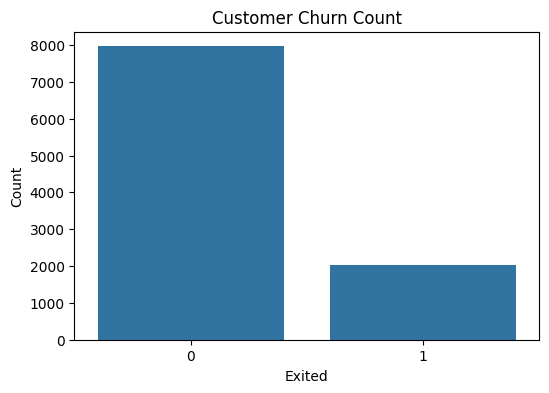

In [9]:
# Count plot of Exited column
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Exited")
plt.title("Customer Churn Count")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()

In this graph, 0 means the customer did not leave the bank, and 1 means the customer left the bank. It helps us understand the distribution of churned and non-churned customers.

## Churn by Geography
This graph shows customer churn according to different geographical locations.

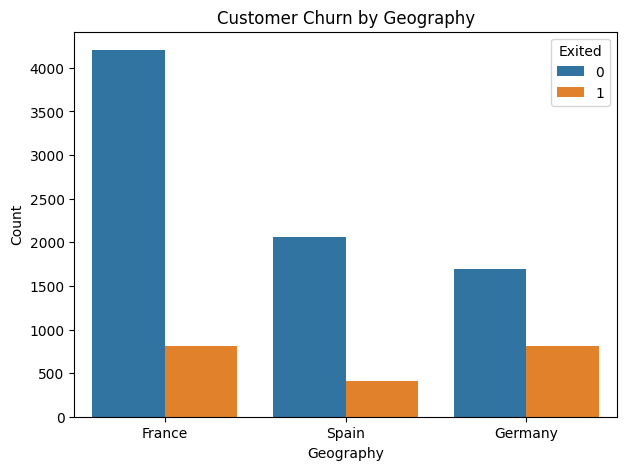

In [10]:
# Geography wise churn
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Geography", hue="Exited")
plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Count")
plt.show()

The graph helps compare how many customers left or stayed in each country. This can help identify which location has a higher churn rate.

## Churn by Gender
This graph shows the relationship between gender and customer churn.

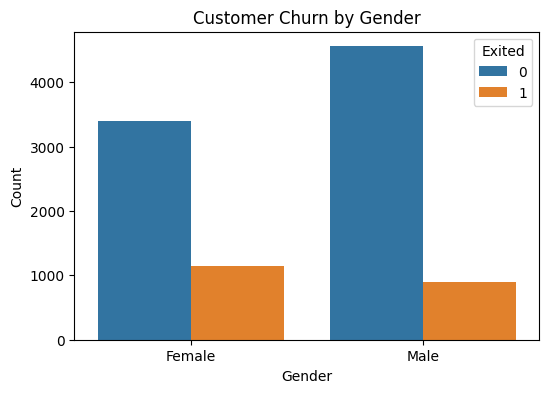

In [11]:
# Gender wise churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", hue="Exited")
plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

The graph helps compare churn behavior between male and female customers.

## Age Distribution
This histogram shows the distribution of customer ages in the dataset.

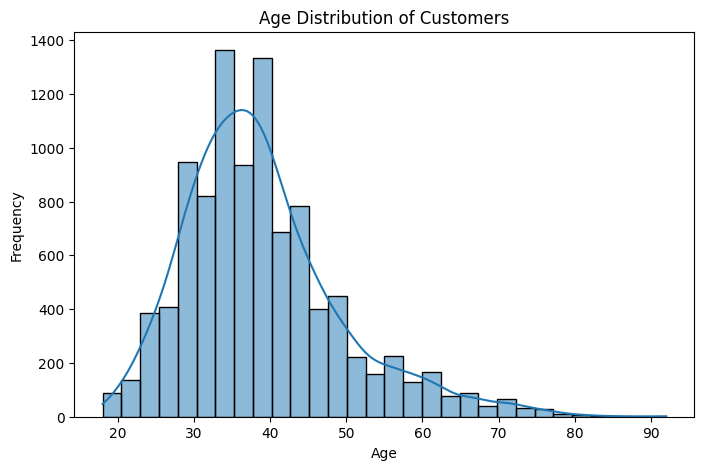

In [12]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The histogram helps us understand the age range of customers and shows which age groups are more common in the dataset.

## Encoding Categorical Features
Categorical columns such as Geography and Gender were converted into numerical form using one-hot encoding because machine learning models work with numerical data.

In [13]:
# Encode categorical columns using one-hot encoding
df_encoded = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)

# Display first 5 rows after encoding
df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


## Feature and Target Selection
The target variable is Exited because we want to predict whether a customer will leave the bank or not. All other columns are used as input features.

In [14]:
# Separate features and target variable
X = df_encoded.drop("Exited", axis=1)
y = df_encoded["Exited"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 11)
Target shape: (10000,)


## Splitting the Dataset
The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate model performance.

In [15]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 11)
Testing data: (2000, 11)


## Model Training
A Decision Tree Classifier was trained to predict customer churn. This model is useful because it can also show feature importance.

In [16]:
# Train Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Model Prediction
The trained model was used to predict whether customers in the test data are likely to leave the bank or not.

In [17]:
# Make predictions
y_pred = model.predict(X_test)

# Display first 10 predictions
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

## Model Evaluation
The model was evaluated using accuracy and confusion matrix. Accuracy shows how many predictions were correct. The confusion matrix shows correct and incorrect predictions for both churned and non-churned customers.

In [18]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.7805
Confusion Matrix:
[[1362  245]
 [ 194  199]]


## Confusion Matrix Visualization
This heatmap shows the confusion matrix in visual form. It helps us understand how many customers were correctly and incorrectly classified by the model.

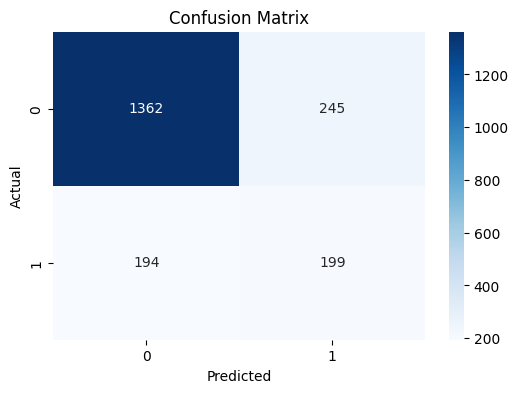

In [20]:
# Confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The classification report shows precision, recall, F1-score, and support. These metrics help us understand the model performance in more detail.

In [21]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1607
           1       0.45      0.51      0.48       393

    accuracy                           0.78      2000
   macro avg       0.66      0.68      0.67      2000
weighted avg       0.79      0.78      0.79      2000



## Feature Importance
Feature importance shows which features were most useful for predicting customer churn.

In [22]:
# Feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,Age,0.223617
7,EstimatedSalary,0.154296
3,Balance,0.154128
0,CreditScore,0.142077
4,NumOfProducts,0.119173
2,Tenure,0.075357
6,IsActiveMember,0.067440
8,Geography_Germany,0.023319
10,Gender_Male,0.016517
5,HasCrCard,0.013267


## Feature Importance Visualization
This graph shows the most important features used by the Decision Tree model for predicting customer churn.

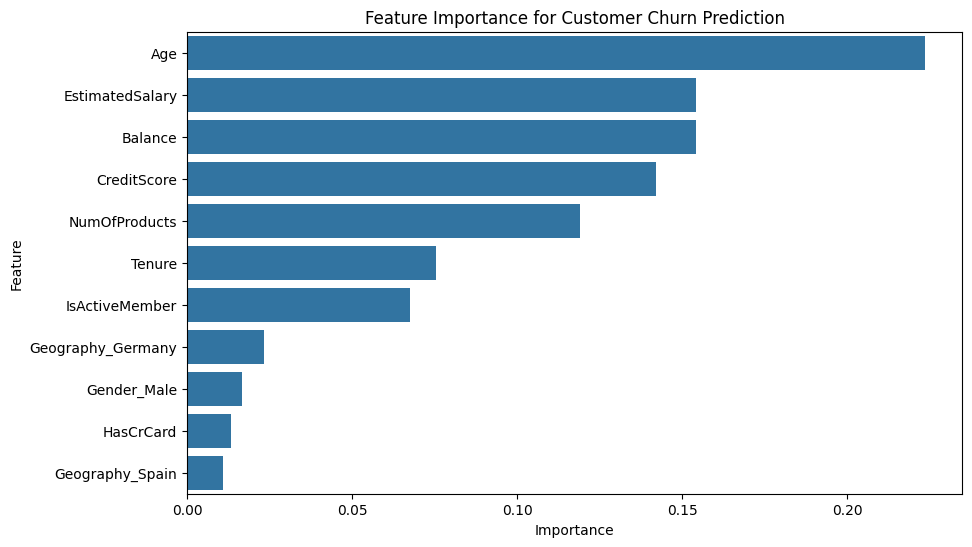

In [23]:
# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance for Customer Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance graph helps identify which customer details have the strongest effect on churn prediction. Features with higher importance values have a greater effect on the model's decision.

## Conclusion

In this project, the Churn Modelling Dataset was used to predict whether a bank customer is likely to leave the bank. The dataset was loaded and explored using pandas. Missing values and duplicate records were checked. Unnecessary columns such as RowNumber, CustomerId, and Surname were removed. Categorical features such as Geography and Gender were converted into numerical form using one-hot encoding.

A Decision Tree Classifier was trained to predict customer churn. The model was evaluated using accuracy, confusion matrix, and classification report. Feature importance was also analyzed to understand which features had the most effect on customer churn prediction. This project helped in understanding classification modeling, categorical encoding, and feature importance analysis.